<a href="https://colab.research.google.com/github/akemitti/Pred-inad-credito/blob/main/notebook04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 04 — Extração Unificada de Sentimento dos Documentos do Bacen

Este notebook executa, em uma única rotina, a extração dos scores de sentimento para:

- Atas do Copom;
- Relatórios de Estatísticas Monetárias e de Crédito.

A entrada esperada é `base_relatorios.csv`, gerada no Notebook 03, contendo pelo menos as colunas:

- `data`;
- `arquivo`;
- `tipo`;
- `texto`.

A saída principal é `base_sentimentos.csv`:

`data`, `tipo_relatorio`, `arquivo`, `tipo`, `score_nltk`, `score_textblob`, `score_bert`, `score_finbert`, `score_mistral`.

## Decisão metodológica central

Todos os modelos recebem o mesmo texto tratado e percorrem o documento completo por meio de janelas textuais. Isso evita que alguns modelos analisem apenas o início do documento e outros apenas o final.

O tratamento textual adotado é intencionalmente conservador: normalização Unicode, remoção de quebras artificiais, correção de hifenização de linha e padronização de espaços. Não são aplicadas etapas agressivas, como remoção de stopwords, stemming, lematização ou remoção de pontuação, porque essas técnicas podem prejudicar modelos baseados em contexto, como BERT, FinBERT e Mistral.

## 0. Instalação das dependências

In [1]:
%pip install -q pandas numpy matplotlib seaborn tqdm nltk textblob transformers torch
%pip install -q ollama

## 1. Imports e parâmetros globais

In [2]:
import os
import re
import json
import math
import unicodedata
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# -------------------------------------------------------------------------
# Entradas e saídas
# -------------------------------------------------------------------------
ARQUIVO_ENTRADA = "base_relatorios.csv"
ARQUIVO_SAIDA = "base_sentimentos.csv"

# URL alternativa, caso o arquivo não esteja no diretório local
URL_BASE = "https://raw.githubusercontent.com/akemitti/Pred-inad-credito/main/base_relatorios.csv"

# -------------------------------------------------------------------------
# Tipos de documento analisados
# -------------------------------------------------------------------------
TIPOS_ANALISAR = ["copom", "estatisticas"]

# -------------------------------------------------------------------------
# Tratamento e segmentação
# -------------------------------------------------------------------------
CHUNK_WORDS = 250          # tamanho aproximado da janela textual
MIN_WORDS_CHUNK = 20       # ignora fragmentos muito curtos
MAX_CHUNKS_DOC = None      # None = usa o documento completo

# -------------------------------------------------------------------------
# Execução dos modelos
# -------------------------------------------------------------------------
RUN_NLTK = True
RUN_TEXTBLOB = True
RUN_BERT = True
RUN_FINBERT = True

# Mistral pode ser demorado. Ative somente quando o Ollama estiver disponível.
RUN_MISTRAL = True

# Nome do modelo no Ollama
MISTRAL_MODEL = "mistral"

# Checkpoint para evitar perda de progresso do Mistral
CHECKPOINT_MISTRAL = "checkpoint_mistral_chunks.jsonl"

# -------------------------------------------------------------------------
# Reprodutibilidade operacional
# -------------------------------------------------------------------------
np.random.seed(42)

## 2. Carregamento da base consolidada do Notebook 03

In [3]:
def carregar_base_relatorios(caminho_local=ARQUIVO_ENTRADA, url_base=URL_BASE):
    if Path(caminho_local).exists():
        df = pd.read_csv(caminho_local)
        print(f"Base carregada do arquivo local: {caminho_local}")
    else:
        df = pd.read_csv(url_base)
        print("Base carregada do GitHub.")

    df.columns = [str(c).strip().lower() for c in df.columns]

    colunas_obrigatorias = {"data", "arquivo", "tipo", "texto"}
    faltantes = colunas_obrigatorias - set(df.columns)
    if faltantes:
        raise ValueError(f"Colunas obrigatórias ausentes na base: {faltantes}")

    df["data"] = pd.to_datetime(df["data"], errors="coerce")
    df["arquivo"] = df["arquivo"].fillna("").astype(str)
    df["tipo"] = df["tipo"].fillna("").astype(str).str.lower().str.strip()
    df["texto"] = df["texto"].fillna("").astype(str)

    df = df[df["tipo"].isin(TIPOS_ANALISAR)].copy()
    df = df.dropna(subset=["data"]).sort_values(["tipo", "data"]).reset_index(drop=True)

    return df

df_docs = carregar_base_relatorios()

print(f"Total de documentos analisáveis: {len(df_docs)}")
print(df_docs["tipo"].value_counts())
print(f"Período: {df_docs['data'].min().date()} → {df_docs['data'].max().date()}")

df_docs[["data", "arquivo", "tipo"]].head()

Base carregada do GitHub.
Total de documentos analisáveis: 134
tipo
estatisticas    81
copom           53
Name: count, dtype: int64
Período: 2019-01-01 → 2025-12-10


,data,arquivo,tipo
0,2019-02-06,COPOM220-not20190206220.pdf,copom
1,2019-03-20,COPOM221-not20190320221.pdf,copom
2,2019-05-08,COPOM222-not20190508222.pdf,copom
3,2019-06-19,Copom223-not20190619223.pdf,copom
4,2019-07-31,Copom224-not20190731224.pdf,copom


## 3. Tratamento textual conservador

O objetivo desta etapa é padronizar o texto sem destruir informação semântica.

Tratamentos aplicados:

1. normalização Unicode;
2. remoção de caracteres invisíveis;
3. correção de hifenização gerada por quebra de linha;
4. substituição de múltiplos espaços por um único espaço;
5. remoção de textos vazios ou extremamente curtos.

Tratamentos propositalmente não aplicados:

- remoção de stopwords;
- stemming;
- lematização;
- conversão integral para minúsculas;
- remoção ampla de pontuação.

Essas etapas foram evitadas porque os modelos contextuais dependem da estrutura original da frase para interpretar o tom do documento.

In [4]:
def limpar_texto_documento(texto: str) -> str:
    """
    Tratamento textual conservador para documentos do Bacen.

    A função preserva pontuação, acentos, ordem das palavras e estrutura básica
    das sentenças, pois esses elementos são relevantes para modelos contextuais.
    """
    if pd.isna(texto):
        return ""

    texto = str(texto)
    texto = unicodedata.normalize("NFC", texto)

    # Remove caracteres invisíveis comuns em extrações de PDF.
    texto = re.sub(r"[\u200b\ufeff]", " ", texto)

    # Corrige hifenização em quebra de linha: "polí-\\n tica" -> "política".
    texto = re.sub(r"([A-Za-zÀ-ÿ])-\s+([A-Za-zÀ-ÿ])", r"\1\2", texto)

    # Normaliza espaços, quebras e tabulações.
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto


def contar_palavras(texto: str) -> int:
    return len(re.findall(r"\b\w+\b", str(texto), flags=re.UNICODE))


df_docs["texto_limpo"] = df_docs["texto"].apply(limpar_texto_documento)
df_docs["n_chars"] = df_docs["texto_limpo"].str.len()
df_docs["n_palavras"] = df_docs["texto_limpo"].apply(contar_palavras)

print(df_docs[["n_chars", "n_palavras"]].describe().round(2))

# Remove documentos sem conteúdo textual suficiente.
df_docs = df_docs[df_docs["n_palavras"] >= MIN_WORDS_CHUNK].copy().reset_index(drop=True)

print(f"Documentos após filtro mínimo de texto: {len(df_docs)}")
df_docs[["data", "tipo", "arquivo", "n_palavras"]].head()

        n_chars  n_palavras
count    134.00      134.00
mean   12474.04     2186.80
std     4519.89      675.93
min     5615.00     1122.00
25%     8557.50     1622.00
50%    12204.00     2035.00
75%    15656.00     2711.50
max    24064.00     3829.00
Documentos após filtro mínimo de texto: 134


,data,tipo,arquivo,n_palavras
0,2019-02-06,copom,COPOM220-not20190206220.pdf,2270
1,2019-03-20,copom,COPOM221-not20190320221.pdf,2493
2,2019-05-08,copom,COPOM222-not20190508222.pdf,2620
3,2019-06-19,copom,Copom223-not20190619223.pdf,2522
4,2019-07-31,copom,Copom224-not20190731224.pdf,2795


## 4. Segmentação comparável em janelas textuais

A limitação central dos modelos baseados em transformer é que eles não conseguem receber documentos longos em uma única entrada.

Para tornar a comparação mais defensável, todos os modelos usam a mesma base textual: o documento tratado completo. Quando o documento é longo, ele é dividido em janelas de aproximadamente `CHUNK_WORDS` palavras. O score final do documento é a média ponderada dos scores das janelas pelo número de palavras de cada janela.

Essa escolha evita três problemas da versão anterior:

1. VADER e TextBlob analisarem apenas os primeiros caracteres;
2. Mistral analisar apenas o final do documento;
3. BERT ser truncado por caracteres em vez de respeitar a limitação de tokens do modelo.

In [5]:
def gerar_chunks_palavras(texto: str, chunk_words: int = CHUNK_WORDS, min_words: int = MIN_WORDS_CHUNK):
    palavras = str(texto).split()

    if MAX_CHUNKS_DOC is None:
        limite = len(palavras)
    else:
        limite = min(len(palavras), MAX_CHUNKS_DOC * chunk_words)

    palavras = palavras[:limite]

    chunks = []
    for i in range(0, len(palavras), chunk_words):
        parte = palavras[i:i + chunk_words]
        if len(parte) >= min_words:
            chunks.append({
                "chunk_id": len(chunks),
                "texto_chunk": " ".join(parte),
                "n_palavras_chunk": len(parte)
            })

    return chunks


def media_ponderada(scores, pesos):
    scores_validos = []
    pesos_validos = []

    for s, p in zip(scores, pesos):
        if s is not None and not pd.isna(s):
            scores_validos.append(float(s))
            pesos_validos.append(float(p))

    if not scores_validos:
        return np.nan

    return float(np.average(scores_validos, weights=pesos_validos))


# Tabela auxiliar de chunks para auditoria metodológica.
linhas_chunks = []

for idx, row in df_docs.iterrows():
    chunks = gerar_chunks_palavras(row["texto_limpo"])
    for ch in chunks:
        linhas_chunks.append({
            "doc_id": idx,
            "data": row["data"],
            "arquivo": row["arquivo"],
            "tipo": row["tipo"],
            **ch
        })

df_chunks = pd.DataFrame(linhas_chunks)

print(f"Total de chunks gerados: {len(df_chunks)}")
print(df_chunks.groupby("tipo")["chunk_id"].count())
df_chunks.head()

Total de chunks gerados: 1146
tipo
copom           571
estatisticas    575
Name: chunk_id, dtype: int64


,doc_id,data,arquivo,tipo,chunk_id,texto_chunk,n_palavras_chunk
0,0,2019-02-06,COPOM220-not20190206220.pdf,copom,0,Ata da 220ª Reunião do Comitê de Política Mone...,250
1,0,2019-02-06,COPOM220-not20190206220.pdf,copom,1,Fernando Alberto Sampaio Rocha – Chefe do Depa...,250
2,0,2019-02-06,COPOM220-not20190206220.pdf,copom,2,se encontram em níveis apropriados ou confortá...,250
3,0,2019-02-06,COPOM220-not20190206220.pdf,copom,3,"peso nos dois últimos riscos listados abaixo, ...",250
4,0,2019-02-06,COPOM220-not20190206220.pdf,copom,4,para a retomada da atividade econômica e da tr...,250


## 5. Funções de aplicação por documento

Esta função aplica um modelo em todos os chunks de um documento e retorna um score agregado no nível do documento.

In [6]:
def aplicar_modelo_por_documento(df_docs, funcao_score, nome_score: str):
    resultados = []

    for idx, row in tqdm(df_docs.iterrows(), total=len(df_docs), desc=nome_score):
        chunks = gerar_chunks_palavras(row["texto_limpo"])

        if not chunks:
            resultados.append(np.nan)
            continue

        scores = []
        pesos = []

        for ch in chunks:
            try:
                score = funcao_score(ch["texto_chunk"])
                if score is not None and not pd.isna(score):
                    score = max(-1.0, min(1.0, float(score)))
            except Exception as e:
                score = np.nan

            scores.append(score)
            pesos.append(ch["n_palavras_chunk"])

        resultados.append(media_ponderada(scores, pesos))

    return resultados

## 6. Modelo NLTK/VADER

O VADER é mantido como baseline léxico. A limitação metodológica permanece: ele foi originalmente desenvolvido para inglês e linguagem geral. Por isso, seus resultados devem ser interpretados como referência comparativa simples, não como principal medida de sentimento econômico.

In [7]:
if RUN_NLTK:
    import nltk
    nltk.download("vader_lexicon", quiet=True)
    from nltk.sentiment.vader import SentimentIntensityAnalyzer

    _sid = SentimentIntensityAnalyzer()

    def score_vader_chunk(texto_chunk: str) -> float:
        if contar_palavras(texto_chunk) < MIN_WORDS_CHUNK:
            return np.nan
        return float(_sid.polarity_scores(texto_chunk)["compound"])

    df_docs["score_nltk"] = aplicar_modelo_por_documento(df_docs, score_vader_chunk, "score_nltk")
else:
    df_docs["score_nltk"] = np.nan

df_docs[["data", "tipo", "score_nltk"]].head()

score_nltk:   0%|          | 0/134 [00:00<?, ?it/s]

,data,tipo,score_nltk
0,2019-02-06,copom,-0.321211
1,2019-03-20,copom,-0.367144
2,2019-05-08,copom,-0.474129
3,2019-06-19,copom,-0.368450
4,2019-07-31,copom,-0.395428


## 7. Modelo TextBlob

O TextBlob também é mantido como baseline léxico. Assim como o VADER, sua limitação é a menor aderência ao português e ao domínio de comunicação de política monetária.

In [8]:
if RUN_TEXTBLOB:
    from textblob import TextBlob

    def score_textblob_chunk(texto_chunk: str) -> float:
        if contar_palavras(texto_chunk) < MIN_WORDS_CHUNK:
            return np.nan
        return float(TextBlob(texto_chunk).sentiment.polarity)

    df_docs["score_textblob"] = aplicar_modelo_por_documento(df_docs, score_textblob_chunk, "score_textblob")
else:
    df_docs["score_textblob"] = np.nan

df_docs[["data", "tipo", "score_textblob"]].head()

score_textblob:   0%|          | 0/134 [00:00<?, ?it/s]

,data,tipo,score_textblob
0,2019-02-06,copom,0.030093
1,2019-03-20,copom,-0.004187
2,2019-05-08,copom,0.019940
3,2019-06-19,copom,0.033056
4,2019-07-31,copom,0.029630


## 8. Modelo BERT Multilingual

O modelo `nlptown/bert-base-multilingual-uncased-sentiment` retorna classes de 1 a 5 estrelas. A transformação para a escala comum é:

`score = (estrelas - 3) / 2`

Assim, 1 estrela equivale a -1, 3 estrelas a 0 e 5 estrelas a +1.

A limitação metodológica é que esse BERT é multilíngue, mas genérico: ele não foi treinado especificamente para documentos do Banco Central nem para interpretação hawkish/dovish.

In [9]:
if RUN_BERT:
    import torch
    from transformers import pipeline as hf_pipeline

    _bert_model = "nlptown/bert-base-multilingual-uncased-sentiment"
    _device_id = 0 if torch.cuda.is_available() else -1

    _bert_pipe = hf_pipeline(
        "sentiment-analysis",
        model=_bert_model,
        tokenizer=_bert_model,
        device=_device_id,
        truncation=True,
        max_length=512,
    )

    def score_bert_chunk(texto_chunk: str) -> float:
        if contar_palavras(texto_chunk) < MIN_WORDS_CHUNK:
            return np.nan

        res = _bert_pipe(texto_chunk)[0]
        estrelas = int(str(res["label"]).split()[0])
        return float((estrelas - 3) / 2)

    df_docs["score_bert"] = aplicar_modelo_por_documento(df_docs, score_bert_chunk, "score_bert")
else:
    df_docs["score_bert"] = np.nan

df_docs[["data", "tipo", "score_bert"]].head()

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

score_bert:   0%|          | 0/134 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,data,tipo,score_bert
0,2019-02-06,copom,0.111111
1,2019-03-20,copom,-0.002412
2,2019-05-08,copom,-0.047856
3,2019-06-19,copom,0.050000
4,2019-07-31,copom,0.030835


## 9. Modelo FinBERT-PT-BR

O FinBERT-PT-BR é mais aderente ao projeto por ter sido treinado para textos financeiros em português.

O score final é calculado como:

`score_finbert = probabilidade_positivo - probabilidade_negativo`

Esse procedimento preserva a informação probabilística do modelo e gera um indicador contínuo entre -1 e +1.

In [10]:
if RUN_FINBERT:
    import torch
    import torch.nn.functional as F
    from transformers import AutoTokenizer, AutoModelForSequenceClassification

    _finbert_name = "lucas-leme/FinBERT-PT-BR"
    _device = "cuda" if torch.cuda.is_available() else "cpu"

    _finbert_tok = AutoTokenizer.from_pretrained(_finbert_name)
    _finbert_model = AutoModelForSequenceClassification.from_pretrained(_finbert_name).to(_device).eval()

    def _pt_label_finbert(i: int) -> str:
        label = str(_finbert_model.config.id2label.get(i, "")).lower()
        if "pos" in label:
            return "positivo"
        if "neg" in label:
            return "negativo"
        return "neutro"

    def score_finbert_chunk(texto_chunk: str) -> float:
        if contar_palavras(texto_chunk) < MIN_WORDS_CHUNK:
            return np.nan

        enc = _finbert_tok(
            texto_chunk,
            return_tensors="pt",
            truncation=True,
            max_length=512
        )
        enc = {k: v.to(_device) for k, v in enc.items()}

        with torch.no_grad():
            logits = _finbert_model(**enc).logits
            probs = F.softmax(logits, dim=-1).squeeze(0).cpu().numpy()

        probs_por_label = {
            _pt_label_finbert(i): float(probs[i])
            for i in range(len(probs))
        }

        return probs_por_label.get("positivo", 0.0) - probs_por_label.get("negativo", 0.0)

    df_docs["score_finbert"] = aplicar_modelo_por_documento(df_docs, score_finbert_chunk, "score_finbert")
else:
    df_docs["score_finbert"] = np.nan

df_docs[["data", "tipo", "score_finbert"]].head()

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/559 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: lucas-leme/FinBERT-PT-BR
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


score_finbert:   0%|          | 0/134 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

,data,tipo,score_finbert
0,2019-02-06,copom,-0.312608
1,2019-03-20,copom,-0.354887
2,2019-05-08,copom,-0.304247
3,2019-06-19,copom,-0.292347
4,2019-07-31,copom,-0.306389


## 10. Modelo Mistral via Ollama

O Mistral é o modelo mais flexível semanticamente porque recebe uma instrução explícita para interpretar o texto no contexto de comunicação do Banco Central.

Nesta versão, o Mistral também usa os mesmos chunks do documento completo. Isso corrige a limitação anterior, em que o modelo analisava apenas os últimos caracteres do documento.

Como o processamento pode ser demorado, o notebook salva um checkpoint por chunk.

In [17]:
!apt-get update
!apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh
!which ollama
!nohup ollama serve >/tmp/ollama.log 2>&1 &
!sleep 5
!ollama pull mistral
!ollama run mistral "Qual é a capital do Brasil?"

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:5 https://cli.github.com/packages stable InRelease [3,917 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,004 kB]
Get:11 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [91.2 kB]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:13 http://security.ubuntu.com/ubuntu jammy-security

In [18]:
def carregar_checkpoint_mistral(caminho=CHECKPOINT_MISTRAL):
    if not Path(caminho).exists():
        return {}

    cache = {}
    with open(caminho, "r", encoding="utf-8") as f:
        for linha in f:
            try:
                item = json.loads(linha)
                cache[item["chave"]] = item["score"]
            except Exception:
                continue
    return cache


def salvar_checkpoint_mistral(chave, score, caminho=CHECKPOINT_MISTRAL):
    with open(caminho, "a", encoding="utf-8") as f:
        f.write(json.dumps({"chave": chave, "score": score}, ensure_ascii=False) + "\n")


SYSTEM_PROMPT_MISTRAL = """
Você é um economista especializado em política monetária, crédito e comunicação do Banco Central do Brasil.

Analise o tom do trecho abaixo considerando o contexto econômico e financeiro brasileiro.

Atribua um score entre -1.0 e 1.0:
-1.0 = tom muito negativo, restritivo, hawkish ou associado a maior risco econômico/financeiro;
 0.0 = tom neutro ou predominantemente descritivo;
 1.0 = tom muito positivo, expansionista, dovish ou associado a menor risco econômico/financeiro.

Responda exclusivamente com um JSON válido contendo apenas a chave "score".

Exemplo:
{"score": -0.35}
"""


def score_mistral_chunk(texto_chunk: str, chave: str, cache: dict) -> float:
    if contar_palavras(texto_chunk) < MIN_WORDS_CHUNK:
        return np.nan

    if chave in cache:
        return cache[chave]

    import ollama

    response = ollama.chat(
        model=MISTRAL_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT_MISTRAL},
            {"role": "user", "content": texto_chunk}
        ],
        options={"temperature": 0.2},
        format="json"
    )

    response_text = response["message"]["content"]
    data = json.loads(response_text)

    score = float(data.get("score", np.nan))
    score = max(-1.0, min(1.0, score))

    salvar_checkpoint_mistral(chave, score)
    cache[chave] = score

    return score


if RUN_MISTRAL:
    cache_mistral = carregar_checkpoint_mistral()

    resultados_mistral = []

    for idx, row in tqdm(df_docs.iterrows(), total=len(df_docs), desc="score_mistral"):
        chunks = gerar_chunks_palavras(row["texto_limpo"])

        scores = []
        pesos = []

        for ch in chunks:
            chave = f"{row['tipo']}|{row['data'].date()}|{row['arquivo']}|{ch['chunk_id']}"
            try:
                score = score_mistral_chunk(ch["texto_chunk"], chave, cache_mistral)
            except Exception as e:
                print(f"Erro Mistral em {chave}: {e}")
                score = np.nan

            scores.append(score)
            pesos.append(ch["n_palavras_chunk"])

        resultados_mistral.append(media_ponderada(scores, pesos))

    df_docs["score_mistral"] = resultados_mistral
else:
    df_docs["score_mistral"] = np.nan
    print("Mistral não executado. Para gerar score_mistral, defina RUN_MISTRAL = True e rode novamente.")

df_docs[["data", "tipo", "score_mistral"]].head()

score_mistral:   0%|          | 0/134 [00:00<?, ?it/s]

,data,tipo,score_mistral
0,2019-02-06,copom,0.005556
1,2019-03-20,copom,-0.058400
2,2019-05-08,copom,0.166654
3,2019-06-19,copom,0.060000
4,2019-07-31,copom,0.325654


## 11. Base final de sentimentos

A base final mantém a mesma estrutura usada nos notebooks posteriores.

In [20]:
score_cols = [
    "score_nltk",
    "score_textblob",
    "score_bert",
    "score_finbert",
    "score_mistral"
]

for col in score_cols:
    if col not in df_docs.columns:
        df_docs[col] = np.nan

for col in score_cols:
    df_docs[col] = pd.to_numeric(df_docs[col], errors="coerce").clip(-1, 1)

df_final = df_docs.copy()
df_final["tipo_relatorio"] = df_final["tipo"]

colunas_finais = [
    "data",
    "tipo_relatorio",
    "arquivo",
    "tipo",
    "score_nltk",
    "score_textblob",
    "score_bert",
    "score_finbert",
    "score_mistral"
]

df_final = df_final[colunas_finais].sort_values(["tipo_relatorio", "data"]).reset_index(drop=True)

print(f"Registros finais: {len(df_final)}")
print(df_final["tipo_relatorio"].value_counts())
print(df_final[score_cols].describe().round(4))

df_final.head()

Registros finais: 134
tipo_relatorio
estatisticas    81
copom           53
Name: count, dtype: int64
       score_nltk  score_textblob  score_bert  score_finbert  score_mistral
count    134.0000        134.0000    134.0000       134.0000       134.0000
mean      -0.6561         -0.0696     -0.6138        -0.0796        -0.2055
std        0.2001          0.0826      0.4274         0.3074         0.2346
min       -0.9468         -0.3223     -1.0000        -0.6017        -0.7073
25%       -0.8510         -0.1263     -1.0000        -0.3584        -0.3844
50%       -0.7053         -0.0644     -0.8792        -0.0803        -0.2053
75%       -0.4678         -0.0066     -0.1427         0.2001        -0.0555
max       -0.3023          0.1254      0.1250         0.5889         0.3986


,data,tipo_relatorio,arquivo,tipo,score_nltk,score_textblob,score_bert,score_finbert,score_mistral
0,2019-02-06,copom,COPOM220-not20190206220.pdf,copom,-0.321211,0.030093,0.111111,-0.312608,0.005556
1,2019-03-20,copom,COPOM221-not20190320221.pdf,copom,-0.367144,-0.004187,-0.002412,-0.354887,-0.058400
2,2019-05-08,copom,COPOM222-not20190508222.pdf,copom,-0.474129,0.019940,-0.047856,-0.304247,0.166654
3,2019-06-19,copom,Copom223-not20190619223.pdf,copom,-0.368450,0.033056,0.050000,-0.292347,0.060000
4,2019-07-31,copom,Copom224-not20190731224.pdf,copom,-0.395428,0.029630,0.030835,-0.306389,0.325654


## 12. Auditoria de comparabilidade

Esta etapa verifica se:

1. todos os modelos estão na escala [-1, 1];
2. há ausência de scores;
3. o número de documentos por tipo está coerente;
4. a base final preserva as datas e tipos de documento.

In [21]:
resumo_modelos = []

for col in score_cols:
    resumo_modelos.append({
        "modelo": col,
        "n": int(df_final[col].notna().sum()),
        "ausentes": int(df_final[col].isna().sum()),
        "min": df_final[col].min(skipna=True),
        "max": df_final[col].max(skipna=True),
        "media": df_final[col].mean(skipna=True),
        "desvio": df_final[col].std(skipna=True),
    })

df_resumo_modelos = pd.DataFrame(resumo_modelos)
df_resumo_modelos

,modelo,n,ausentes,min,max,media,desvio
0,score_nltk,134,0,-0.946805,-0.302276,-0.656129,0.200103
1,score_textblob,134,0,-0.322321,0.125425,-0.069627,0.082552
2,score_bert,134,0,-1.000000,0.125000,-0.613837,0.427362
3,score_finbert,134,0,-0.601696,0.588895,-0.079586,0.307353
4,score_mistral,134,0,-0.707339,0.398644,-0.205456,0.234554


In [22]:
# Validação da escala
for col in score_cols:
    serie = df_final[col].dropna()
    if len(serie) > 0:
        assert serie.between(-1, 1).all(), f"{col} possui valores fora da escala [-1, 1]"

print("Validação concluída: scores dentro da escala [-1, 1].")

Validação concluída: scores dentro da escala [-1, 1].


## 13. Visualização comparativa

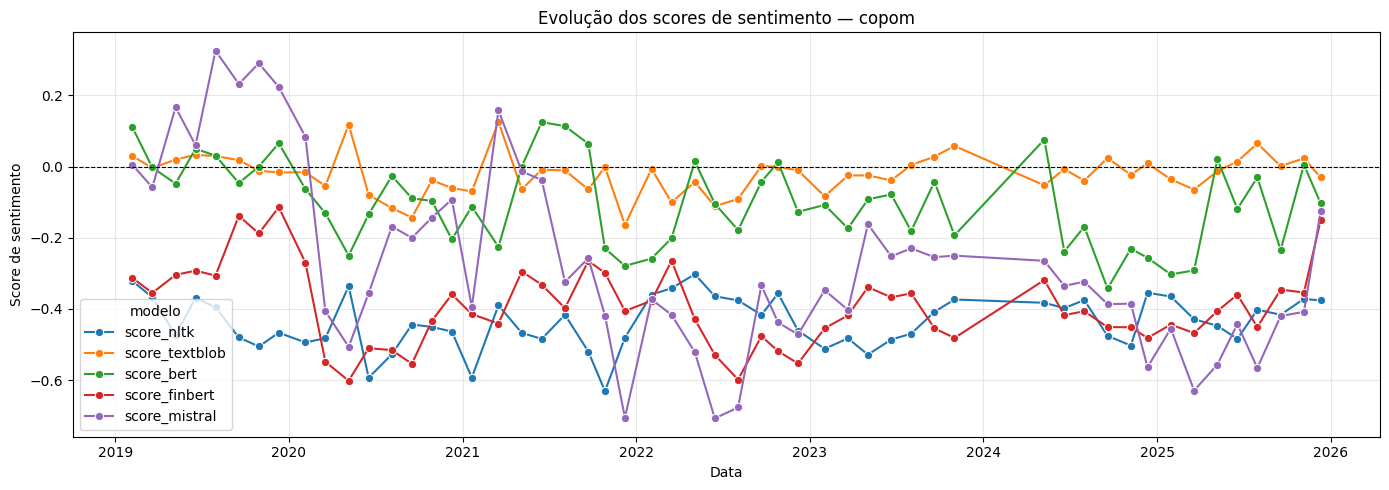

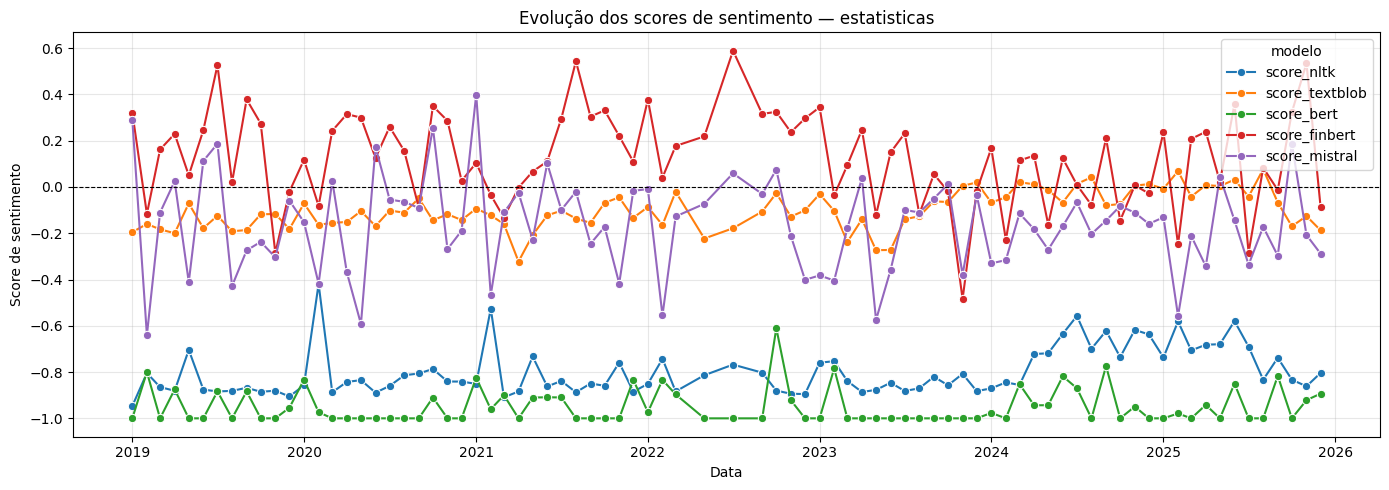

In [23]:
df_plot = df_final.melt(
    id_vars=["data", "tipo_relatorio"],
    value_vars=score_cols,
    var_name="modelo",
    value_name="score"
)

for tipo in df_plot["tipo_relatorio"].dropna().unique():
    dados = df_plot[df_plot["tipo_relatorio"] == tipo].copy()

    plt.figure(figsize=(14, 5))
    sns.lineplot(data=dados, x="data", y="score", hue="modelo", marker="o")
    plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
    plt.title(f"Evolução dos scores de sentimento — {tipo}")
    plt.xlabel("Data")
    plt.ylabel("Score de sentimento")
    plt.tight_layout()
    plt.show()

## 14. Salvamento da base

O arquivo `base_sentimentos.csv` é a saída oficial deste notebook.

In [24]:
df_final.to_csv(ARQUIVO_SAIDA, index=False, encoding="utf-8")
print(f"Arquivo salvo: {ARQUIVO_SAIDA}")

# Compatibilidade com Colab
Path("/content/sample_data").mkdir(parents=True, exist_ok=True)
df_final.to_csv("/content/sample_data/base_sentimentos.csv", index=False, encoding="utf-8")
print("Cópia salva em: /content/sample_data/base_sentimentos.csv")

Arquivo salvo: base_sentimentos.csv
Cópia salva em: /content/sample_data/base_sentimentos.csv
